# Understanding wav2vec 2.0: A Self-Supervised Approach to Speech Representation Learning

# Background and Motivation

**wav2vec 2.0** [1] was developed by Facebook AI to leverage the vast amount of unlabeled speech data available in the world. Traditional automatic speech recognition (ASR) systems require thousands of hours of labeled (transcribed) audio to reach usable accuracy. Acquiring this data would be extremely expensive since such labeled data is scarce for most of the world's nearly 7,000 languages. wav2vec 2.0 addresses this by learning speech representations directly from raw audio without any labels, and using a small amount of labeled data for transcription.

The key contribution of wav2vec 2.0 is that it outperforms semi-supervised methods by pre-training a large transformer-based model on unlabeled audio and then fine-tuning it with very small labeled datasets. The model produces strong results even with as little as 10 minutes of labeled data, demonstrating the power of self-supervised learning in speech.

The specific pre-training technique is a direct adaptation of Masked Language Modeling (MLM), the strategy made famous by BERT [2] in NLP. In BERT, roughly 15% of tokens in a text sequence are randomly masked, and the model is trained to predict the missing tokens using the surrounding context. wav2vec 2.0 adapts this techinique for audio by masking contiguous spans of latent speech representations (compressed feature vectors produced by the CNN encoder from raw audio waveforms). The key difference from the NLP version is that speech does not have discrete units like words. So rather than predicting the original token, the model is trained to identify the correct speech unit from a set of distractors (other audio frames from the same utterance).

## Dataset: LibriSpeech

LibriSpeech is a widely used speech corpus derived from audiobooks. It contains approximately 960 hours of labeled English speech, along with much larger unlabeled extensions (LibriVox). [3]

## Evaluation metric: Word Error Rate (WER)

WER is the standard metric for ASR used to quantify transcription accuracy:

WER = $\frac{\text{Substitutions + Insertions + Deletions}}{\text{Total Reference Words}}$
* Lower WER indicates better performance.
* A score of 0 indicates a perfect transcript
* wav2vec 2.0 achieves as low as 1.8% WER on clean speech, which is near human-level performance.

## Key Ablation Findings

The paper's ablation studies reveal some critical design decisions:

1. The best performance comes from using continuous latent inputs with quantized targets. Quantizing only the targets (and not the inputs) helps the model learn more robust and generalizable representations, while avoiding information loss in the input sequence.
2. Diversity loss is important as without it the model collapses to using only a few codebook entries.
3. Overlapping masked spans outperform non-overlapping strategies.
4. Gumbel noise in the quantizer is essential and removing it causes instability and worse WER.

# Model Architecture

The wav2vec 2.0 model is composed of three major components:

*   A Feature Encoder (CNN)
*   A Transformer (with relative positional encoding)
*   A Quantization Module

Together they map raw audio waveforms to a set of contextualized continuous representations and discrete speech units.

## Feature Encoder

The feature encoder is the first step on the pipeline, extracting features from raw audio files by applying temporal convolution and a GELU activation function. The original model utilized seven blocks with 512 channels for a total stride of 320. Our small-scale implementation has only three blocks with 64 channels and a total stride of 20.

In [ ]:

class FeatureEncoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv = nn.Sequential(
        nn.Conv1d(1, 64, kernel_size = 10, stride = 5, padding = 3),
        nn.GELU(),
        nn.Conv1d(64, 64, kernel_size = 3, stride = 2, padding = 1),
        nn.GELU(),
        nn.Conv1d(64, 64, kernel_size = 3, stride = 2, padding = 1),
        nn.GELU(),
    )

  def forward(self, x):
    return self.conv(x)

## Positional Encoder & Transformer

Applying the breakthroughs in Natural Language Processing, the wav2vec 2.0 model applies a transformer to the encoded features. This is broken into two parts, first the features are run through a positional encoder consisting of a depthwise convolution and a GELU activation function. This returns features with the same shape as the input, but with additional positional information to ensure time-data of the sequence is not lost.

In [ ]:
class PosConv(nn.Module):
  def __init__(self, dim = 64):
    super().__init__()
    self.conv = nn.Conv1d(dim, dim, kernel_size = 9, padding = 4, groups = dim)
    self.act = nn.GELU()
    self.norm = nn.LayerNorm(dim)

  def forward(self, x):
    pos = x.transpose(1,2)
    pos = self.conv(pos)
    pos = self.act(pos)
    pos = pos.transpose(1,2)
    pos = self.norm(pos)
    return x + pos

Next, the features are run through a multi-layer transformer. The original model employed two sizes of transformer. The BASE model utilized 12 blocks, a model dimension of 768, and 8 attention heads, whereas the LARGE model had 24 blocks, a model dimension of 4,096 and 16 attention heads. Our small-scale implementation has only 2 blocks, a model dimension of 128, and 4 attention heads.

In [ ]:
class Transformer(nn.Module):
  def __init__(self, dim = 64):
    super().__init__()
    layer = nn.TransformerEncoderLayer(
        d_model = dim,
        nhead = 4,
        dim_feedforward = 128,
        batch_first = True,
        activation = "gelu"
    )
    self.pre_norm = nn.LayerNorm(dim)
    self.encoder = nn.TransformerEncoder(layer, num_layers = 2)
    self.final_norm = nn.LayerNorm(dim)

  def forward(self, x):
    x = self.pre_norm(x)
    x = self.encoder(x)
    return self.final_norm(x)

## Quantization Module

Finally, the output of the transformer is fed through a quantization module to convert the continous features to a near-one-hot encoding using the Gumbel softmax estimator. This collapses the high-dimensionality of the transformer output into a smaller "codebook" categorizing the sequence of sounds found in the input audio file. The original model assigned all features to 2 codebook groups with 160 entries each for a total of 320 values. Our implementation maintains 2 codebooks, but shrinks the entries in each down to 16.

In [ ]:
class Quantizer(nn.Module):
  def __init__(self, dim = 64, num_groups = 2, num_vars = 32, temp = 2.0, temp_min = 0.5, decay = 1e-5):
    super().__init__()

    self.dim = dim
    self.num_groups = num_groups
    self.vars_per_group = num_vars // num_groups
    self.temp = temp
    self.temp_min = temp_min
    self.decay = decay

    self.codebook = nn.Parameter(torch.randn(num_groups, self.vars_per_group, dim // num_groups))
    self.proj = nn.Linear(dim, num_vars)

  def update_temp(self):
    self.temp = max(self.temp_min, self.temp * (1 - self.decay))

  def forward(self, x, update_temp = True):
    B, T, C = x.shape

    if update_temp:
      self.update_temp()

    logits = self.proj(x)
    logits = logits.view(B, T, self.num_groups, self.vars_per_group)

    gumbels = -torch.empty_like(logits).exponential_().log()
    gumbels = (logits + gumbels)/self.temp

    probs = F.softmax(gumbels, dim = -1)

    codes = probs.argmax(dim = -1)

    quantized = torch.einsum("btgv, gvc -> btgc", probs, self.codebook)
    quantized = quantized.reshape(B, T, C)

    return quantized, codes, probs

# Model Training

Training has two phases: self-supervised pre-training on unlabeled audio and supervised fine-tuning on transcribed speech. This implementation will be focusing on self-supervised pre-training.

## Masker

As a self-supervised model, the wav2vec 2.0 model utilizes masking to learn its encodings. A masking function receives a set of categorized features as input, then randomly "masks" certain segments of the input and returns. These masked features are then run through the trasnformer alongside and the predicted features are compared to the actual features to calculate the loss.

In [ ]:
class Masker(nn.Module):
  def __init__(self, mask_prob = 0.5, mask_length = 5):
    super().__init__()
    self.mask_prob = mask_prob
    self.mask_length = mask_length
    self.mask_embedding = nn.Parameter(torch.randn(1, 1, 64))

  def forward(self, x):
    B, T, C = x.shape
    mask = torch.zeros(B, T, dtype = torch.bool)

    for b in range(B):
      starts = torch.where(torch.rand(T) < self.mask_prob)[0]
      used = torch.zeros(T, dtype = torch.bool)
      for s in starts:
        if s + self.mask_length <=T and not used[s:s+self.mask_length].any():
          mask[b, s:s + self.mask_length] = True
          used[s: s + self.mask_length] = True

    x_masked = x.clone()
    x_masked[mask] = self.mask_embedding

    return x_masked, mask

## Loss Functions

Two loss functions are used during training to asses the model's performance:

### Contrastive loss

This is the value calculated from the masking described above. It represents the transformer's success in accurately predicting the correct codebook entries. To calculate the contrastive loss, the class takes the codebook predictions, targets and mask indices as inputs. It identifies the masked portions of the prediction and target vectors and normalizes.

Here our contrastive loss selects the masked positions, normalizes them to compare based on direction (rather than raw magnitute). We then sample negative examples from target vectors. Using both, we compute positive and negative similarities, and concatenate results into logits. We define the labels with a zero-array, and return the calculated the cross entrophy loss between logits and labels.

In [ ]:
class ContrastiveLoss(nn.Module):
  def __init__(self, temperature = 0.1, num_negatives = 100):
    super().__init__()
    self.temperature = temperature
    self.num_negatives = num_negatives

  def forward(self, preds, targets, mask):
    preds = preds[mask]
    positives = targets[mask]

    preds = preds / (preds.norm(dim = -1, keepdim = True) + 1e-7)
    positives = positives / (positives.norm(dim = -1, keepdim = True) + 1e-7)

    M, C = preds.size()

    all_q = targets[~mask]
    all_q = all_q / (all_q.norm(dim = -1, keepdim = True) + 1e-7)

    if all_q.size(0) < self.num_negatives:
      all_q = targets.reshape(-1, C)
      all_q = all_q / (all_q.norm(dim = -1, keepdim = True) + 1e-7)

    neg_idx = torch.randint(0, all_q.size(0), (M, self.num_negatives))
    negatives = all_q[neg_idx]

    pos_sim = (preds * positives).sum(-1, keepdim = True)
    neg_sim = (preds.unsqueeze(1) * negatives).sum(-1)

    logits = torch.cat([pos_sim, neg_sim], dim = 1) / self.temperature
    labels = torch.zeros(M, dtype = torch.long)

    return nn.CrossEntropyLoss()(logits, labels)

### Diversity loss

This is a separate loss value used to ensure rich feature encoding. It returns a value representing the "entropy" of the codebook probabilities which discourages the model from collapsing into using only a subset of the entries. The diversity loss is minimized when all codebook entries are used equally.

We implement a simple diversity loss by counting the number of times each codebook entry was used (quantizer), and calculate a normalized entropy, and return 1 - entropy. This way we encourage broader use of the quantizer.

In [ ]:
class DiversityLoss(nn.Module):
  def __init__(self, num_vars = 32):
    super().__init__()
    self.num_vars = num_vars

  def forward(self, indices):
    counts = torch.bincount(indices.flatten(), minlength = self.num_vars).float()
    probs = counts / counts.sum()
    entropy = -(probs * (probs + 1e-7).log()).sum()
    entropy = entropy / torch.log(torch.tensor(self.num_vars))
    return 1 - entropy

## Combined Model & Training Objective

The full model wires all components together. The contrastive and diversity losses are combined with weight α = 0.1 as `loss = contrastive_loss + α * diversity_loss`

In [ ]:
class Wav2Vec(nn.Module):
  def __init__(self):
    super().__init__()
    self.encoder = FeatureEncoder()
    self.pos = PosConv()
    self.masker = Masker()
    self.transformer = Transformer()
    self.quantizer = Quantizer()
    self.pred_proj = nn.Linear(64, 64)
    self.cLoss = ContrastiveLoss()
    self.dLoss = DiversityLoss()

  def forward(self, x):
    x = self.encoder(x)
    x = x.transpose(1,2)
    x = self.pos(x)

    x_masked, mask = self.masker(x)
    preds = self.transformer(x_masked)
    preds = self.pred_proj(preds)
    quantized, indices, _ = self.quantizer(x)

    c_loss = self.cLoss(preds, quantized, mask)
    d_loss = self.dLoss(indices)
    return c_loss + 0.1 * d_loss, c_loss, d_loss

Together, these components allow wav2vec 2.0 to learn powerful speech representations from unlabeled data, which can then be fine-tuned downstream for tasks like speech recognition.

# Dataset & Data Loading

The dataset class wraps LibriSpeech .flac files into fixed-length waveform tensors. For a CPU-friendly working example, only a small subset of files is loaded and each clip is truncated or zero-padded to a uniform length of 2 seconds (32,000 samples at 16 kHz).

In [ ]:
class LibriSpeech(Dataset):
    def __init__(self, root, max_files = 20, target_len = 16000*2):
        self.files = list(Path(root).rglob("*.flac"))[:max_files]
        self.target_len = target_len

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        wav, sr = sf.read(self.files[idx])
        wav = torch.tensor(wav, dtype = torch.float32)

        if wav.ndim > 1:
            wav = wav.mean(dim = 1)

        if sr != 16000:
            wav = torchaudio.functional.resample(wav, sr, 16000)

        if len(wav) > self.target_len:
            wav = wav[:self.target_len]
        else:
            pad = self.target_len - len(wav)
            wav = torch.nn.functional.pad(wav, (0, pad))

        return wav.unsqueeze(0)

# Working Example - Pre-Training

In [ ]:
from pathlib import Path
import soundfile as sf
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
!pip install -q gdown
!gdown 1dlnzLnshK8lZPFgJKk6zO_Tu7nj05wPs -O LibriSpeech.zip
!unzip -q LibriSpeech.zip


PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / "LibriSpeech"

train_root = DATA_ROOT / "train-clean-5"
dev_root = DATA_ROOT / "dev-clean-2"


Downloading...
From: https://drive.google.com/uc?id=1dlnzLnshK8lZPFgJKk6zO_Tu7nj05wPs
To: /content/LibriSpeech.zip
100% 15.2M/15.2M [00:00<00:00, 103MB/s] 


We have now defined all of what we need to start pretraining the model on non-labeled data.

# Running Pretraining

The following code block pretrains a wav2vec model using the selected hyperparameters, saves training loss at intervals and creates model checkpoints. Finally, it plots the training loss. (since our model is very tiny, and we heavily under-train, loss will remain high)

Saved checkpoint at 20% of training: wav2vec_pretrained_20pct.pt
[step 5] loss=4.8559 c_loss=4.8334 d_loss=0.2259
Saved checkpoint at 40% of training: wav2vec_pretrained_40pct.pt
[step 10] loss=4.7703 c_loss=4.7475 d_loss=0.2273
Saved checkpoint at 60% of training: wav2vec_pretrained_60pct.pt
[step 15] loss=4.7308 c_loss=4.7083 d_loss=0.2252
Saved checkpoint at 80% of training: wav2vec_pretrained_80pct.pt
[step 20] loss=4.7124 c_loss=4.6896 d_loss=0.2283
Saved checkpoint at 100% of training: wav2vec_pretrained_100pct.pt


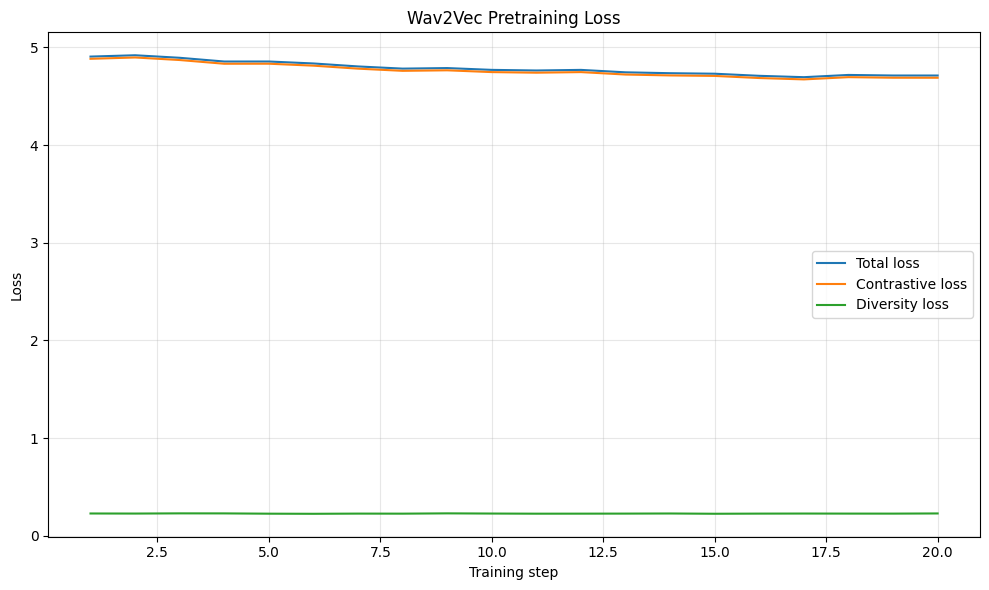

Pretraining complete.


In [ ]:
def plot_losses(steps, total_losses, contrastive_losses, diversity_losses):
    plt.figure(figsize = (10, 6))
    plt.plot(steps, total_losses, label = "Total loss")
    plt.plot(steps, contrastive_losses, label = "Contrastive loss")
    plt.plot(steps, diversity_losses, label = "Diversity loss")
    plt.xlabel("Training step")
    plt.ylabel("Loss")
    plt.title("wav2vec Pretraining Loss")
    plt.legend()
    plt.grid(True, alpha = 0.3)
    plt.tight_layout()
    plt.show()


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset = LibriSpeech(DATA_ROOT)
loader = DataLoader(dataset, batch_size = 4, shuffle = True, num_workers = 0, pin_memory = False)

model = Wav2Vec().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr = 1e-4, weight_decay = 0.01)

num_epochs = 4
total_steps = num_epochs * len(loader)
global_step = 0
loss_steps = []
total_losses = []
contrastive_losses = []
diversity_losses = []
checkpoint_steps = {max(1, int(total_steps * progress / 5)) for progress in range(1, 6)}

model.train()

for _ in range(num_epochs):
    for batch in loader:
        x = batch.to(device)
        loss, c_loss, d_loss = model(x)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        global_step += 1

        loss_steps.append(global_step)
        total_losses.append(loss.item())
        contrastive_losses.append(c_loss.item())
        diversity_losses.append(d_loss.item())

        if global_step % 5 == 0: # Make larger if training longer with GPU
            print(
                f"[step {global_step}] "
                f"loss={loss.item():.4f} "
                f"c_loss={c_loss.item():.4f} "
                f"d_loss={d_loss.item():.4f}"
            )

        if global_step in checkpoint_steps:
            progress_pct = int(round(100 * global_step / total_steps))
            checkpoint_path = f"wav2vec_pretrained_{progress_pct}pct.pt"
            torch.save(model.state_dict(), checkpoint_path)
            print(f"Saved checkpoint at {progress_pct}% of training: {checkpoint_path}")

plot_losses(loss_steps, total_losses, contrastive_losses, diversity_losses)
print("Pretraining complete.")

# Before Proceeding to Fine-Tuning on Labeled Data

All the above code represents the breakthrough that the wav2vec paper provided to the research field, that being pattern identification, and prediction on unlabeled speech files. The following sections will focus on the fine-tuning aspect using the ASR CTC process - a well understood topic in the field. Still, we believe this section is a vital component of the wav2vec findings, and are including it to demonstrate the wav2vec model's ability to translate it's codebook entries into words. This is essential for comparing wav2vec's performance with other transcription models via WER scores.

# Labeled Dataset Loading & Tokenization

We begin by creating a simple tokenization vocabulary, which enumerates the alphabet characters and regex characters such as `'` and `space`. We  also include `<blank>` in the vocab as index 0 to serve as the CTC blank token, which is required to represent the absence of a character at a given timestep. All incoming data is normalized through this vocab (except blank).

We define a simple tokenization process of enumerating the vocabulary and mapping vocab items to indices during encoding. For example, `encode_text("AI")` produces `tensor([2, 10])`, since `'a'` maps to index 2 and `'i'` maps to index 10 in our vocabulary.

We can now define our dataset loader for the labeled data. `LibriSpeechASR()` follows the same schema as `LibriSpeech()`, except it also processes the `.trans.txt` transcript files, retrieving reference transcripts for each audio sample and matching them to the corresponding `.flac` files.

In order to pass uniform data to our finetuning task, we pre-process the audio samples and the reference transcripts with `asr_collate_fn()`. This function cuts the samples into uniform sizes, padding when necessary, and stacks them into a single waveform tensor. Reference transcripts are concatenated into a flat 1D target tensor, as required by `nn.CTCLoss`.

In [ ]:
VOCAB = ["<blank>", "'"] + list("abcdefghijklmnopqrstuvwxyz") + [" "]
VOCAB_MAP = {token: idx for idx, token in enumerate(VOCAB)}

def normalize_text(text):
    text = text.lower()
    allowed = set("abcdefghijklmnopqrstuvwxyz' ")
    return "".join(ch for ch in text if ch in allowed)

def encode_text(text, vocab_map = VOCAB_MAP):
    normalized = normalize_text(text)
    tokens = [vocab_map[ch] for ch in normalized if ch in vocab_map]
    return torch.tensor(tokens, dtype = torch.long)

class LibriSpeechASR(Dataset):
    def __init__(self, root, max_files = 20, target_len = 16000*2):
        self.root = Path(root)
        self.samples = []
        self.target_len = target_len

        transcript_map = {}
        for transcript_file in self.root.rglob("*.trans.txt"):
            for line in transcript_file.read_text().splitlines():
                parts = line.strip().split(maxsplit = 1)
                if len(parts) == 2:
                    transcript_map[parts[0]] = parts[1]

        for audio_path in sorted(self.root.rglob("*.flac")):
            utt_id = audio_path.stem
            if utt_id in transcript_map:
                self.samples.append((audio_path, transcript_map[utt_id]))

        if max_files is not None:
            self.samples = self.samples[:max_files]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        audio_path, transcript = self.samples[idx]
        wav, sr = sf.read(audio_path)
        wav = torch.tensor(wav, dtype = torch.float32)

        if wav.ndim > 1:
            wav = wav.mean(dim = 1)

        if sr != 16000:
            wav = torchaudio.functional.resample(wav, sr, 16000)

        if len(wav) > self.target_len:
            wav = wav[:self.target_len]
        else:
            pad = self.target_len - len(wav)
            wav = torch.nn.functional.pad(wav, (0, pad))

        token_ids = encode_text(transcript)
        return {
            "waveform": wav.unsqueeze(0),
            "input_length": wav.size(0),
            "targets": token_ids,
            "target_length": token_ids.size(0),
            "transcript": normalize_text(transcript),
            "utt_id": audio_path.stem,
        }

def asr_collate_fn(batch):
    input_lengths = torch.tensor([item["input_length"] for item in batch], dtype = torch.long)
    target_lengths = torch.tensor([item["target_length"] for item in batch], dtype = torch.long)
    max_input_len = int(input_lengths.max().item())

    padded_waveforms = []
    for item in batch:
        wav = item["waveform"]
        pad = max_input_len - wav.size(-1)
        if pad > 0:
            wav = torch.nn.functional.pad(wav, (0, pad))
        padded_waveforms.append(wav)

    targets = torch.cat([item["targets"] for item in batch], dim = 0)

    return {
        "waveforms": torch.stack(padded_waveforms, dim = 0),
        "input_lengths": input_lengths,
        "targets": targets,
        "target_lengths": target_lengths,
        "transcripts": [item["transcript"] for item in batch],
        "utt_ids": [item["utt_id"] for item in batch],
    }

# Fine-Tuning Model & Methods

We define `Wav2VecForCTC()`, which adds a CTC classification head on top of the pre-trained `Wav2Vec` backbone. This includes a `CTC` loss function [4], which scores the likelihood of all possible alignments between the predicted token sequence and the reference transcript without requiring explicit frame-level alignment. This is necessary because there is no reliable correspondence between individual audio frames and the characters they represent.

The `forward()` method runs the input waveform through the feature encoder, positional convolution, and transformer (same as pre-training) but skips the masker and quantizer. The transformer output is then passed through a dropout layer and a linear classifier that projects each frame's representation onto logit scores over the vocabulary. A log-softmax is applied to produce log-probabilities suitable for CTC loss. If `input_lengths` are provided, the method also computes the corresponding output lengths.

The `greedy_decode()` method converts log-probability sequences into text transcripts. For each frame it selects the token with the highest probability, then applies CTC's collapsing rule: consecutive duplicate tokens are merged into one, and blank tokens (index 0) are removed. This gives the most likely character sequence.

The function `output_lengths()` calculates the sequence length at the output of the CNN encoder, by propagating each convolution layer's kernel size, stride, and padding. This is essential because the CTC loss requires the true (unpadded) output length for each sample in the batch.

In [ ]:
def output_lengths(input_lengths):
    lengths = input_lengths.clone()
    conv_params = [(10, 5, 3), (3, 2, 1), (3, 2, 1)]
    for kernel_size, stride, padding in conv_params:
        lengths = ((lengths + 2 * padding - (kernel_size - 1) - 1) // stride) + 1
    return lengths.clamp_min(1)

class Wav2VecForCTC(nn.Module):
    def __init__(self, pretrained_checkpoint = None, vocab_size = len(VOCAB), dropout = 0.1):
        super().__init__()
        self.wav2vec = Wav2Vec()
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(64, vocab_size)
        self.ctc_loss = nn.CTCLoss(blank = 0, zero_infinity = True)

        if pretrained_checkpoint is not None:
            state_dict = torch.load(pretrained_checkpoint, map_location = "cpu")
            self.wav2vec.load_state_dict(state_dict, strict = True)

    def forward(self, x, input_lengths = None):
        x = self.wav2vec.encoder(x)
        x = x.transpose(1,2)
        x = self.wav2vec.pos(x)
        x = self.wav2vec.transformer(x)
        logits = self.classifier(self.dropout(x))
        log_probs = logits.log_softmax(dim = -1)

        out_lengths = None
        if input_lengths is not None:
            out_lengths = output_lengths(input_lengths)

        return log_probs, out_lengths

    def compute_loss(self, waveforms, input_lengths, targets, target_lengths):
        log_probs, out_lengths = self(waveforms, input_lengths)
        loss = self.ctc_loss(log_probs.transpose(0, 1), targets, out_lengths, target_lengths)
        return loss, log_probs, out_lengths

    def set_backbone_trainable(self, trainable):
        for param in self.wav2vec.parameters():
            param.requires_grad = trainable

    def greedy_decode(self, log_probs):
        predictions = log_probs.argmax(dim = -1)
        transcripts = []

        for seq in predictions:
            decoded = []
            prev = None
            for idx in seq.tolist():
                if idx != 0 and idx != prev:
                    decoded.append(VOCAB[idx])
                prev = idx
            transcripts.append("".join(decoded).strip())

        return transcripts

We define helper functions to evaluate training loss here. As usual, when evaluating deep learning models, we put models in `eval()` mode to disable training during evaluation.

In [ ]:
def plot_finetuning_losses(epochs, train_losses, val_losses):
    plt.figure(figsize = (10, 6))
    plt.plot(epochs, train_losses, label = "Train CTC loss")
    plt.plot(epochs, val_losses, label = "Validation CTC loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("wav2vec Fine-Tuning Loss")
    plt.legend()
    plt.grid(True, alpha = 0.3)
    plt.tight_layout()
    plt.show()

def evaluate(model, loader, device):
    model.eval()
    total_loss = 0.0
    total_batches = 0

    with torch.no_grad():
        for batch in loader:
            waveforms = batch["waveforms"].to(device)
            input_lengths = batch["input_lengths"].to(device)
            targets = batch["targets"].to(device)
            target_lengths = batch["target_lengths"].to(device)
            loss, _, _ = model.compute_loss(waveforms, input_lengths, targets, target_lengths)
            total_loss += loss.item()
            total_batches += 1

    model.train()
    return total_loss / max(total_batches, 1)

We have now set up everything to start finetuning on our pre-trained models.

# Working Example - Fine-Tuning

Here we load our labeled training dataset, setup a pre-trained model, tune hyperparameters, and start fine-tuning.

For the first epoch we freeze encoder weights to focus on the new fine-tuning layers.

We save the training loss progress, and put out model checkpoints throughout the fine-tuning process. At the end we plot the training loss.

Saved fine-tuning checkpoint at 19%: wav2vec_finetuned_19pct.pt
[epoch 1/4] train_ctc_loss=53.9231 val_ctc_loss=26.4914
[step 10] ctc_loss=17.5476 pred='skscskskskskscsksksksksksksks'
Saved fine-tuning checkpoint at 38%: wav2vec_finetuned_38pct.pt
[epoch 2/4] train_ctc_loss=50.1936 val_ctc_loss=19.2134
Saved fine-tuning checkpoint at 59%: wav2vec_finetuned_59pct.pt
[step 20] ctc_loss=13.3941 pred='s'
[epoch 3/4] train_ctc_loss=40.5767 val_ctc_loss=15.0013
Saved fine-tuning checkpoint at 78%: wav2vec_finetuned_78pct.pt
[step 30] ctc_loss=10.0348 pred='s'
Saved fine-tuning checkpoint at 100%: wav2vec_finetuned_100pct.pt
[epoch 4/4] train_ctc_loss=35.1218 val_ctc_loss=13.7356


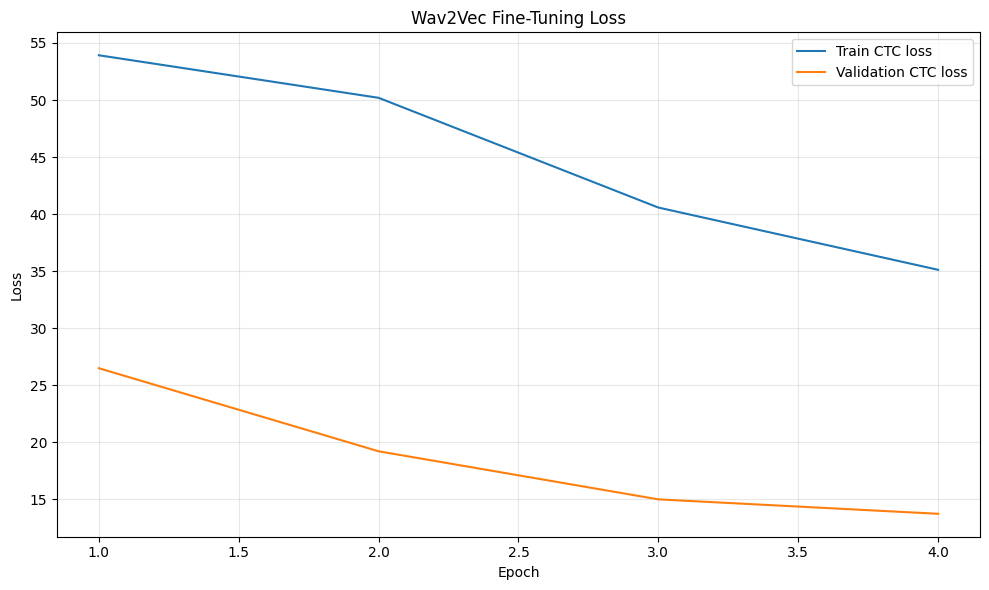

Fine-tuning complete.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_cuda = device.type == "cuda"

pretrained_checkpoint = PROJECT_ROOT / "wav2vec_pretrained_100pct.pt"

train_dataset = LibriSpeechASR(train_root, max_files = 8, target_len = 16000 * 2)
dev_dataset = LibriSpeechASR(dev_root, max_files = 4, target_len = 16000 * 2)

train_loader = DataLoader(
    train_dataset,
    batch_size = 1,
    shuffle = True,
    collate_fn = asr_collate_fn,
    num_workers = 0,
    pin_memory = use_cuda,
)
dev_loader = DataLoader(
    dev_dataset,
    batch_size = 1,
    shuffle = False,
    collate_fn = asr_collate_fn,
    num_workers = 0,
    pin_memory = use_cuda,
)

checkpoint_path = pretrained_checkpoint if pretrained_checkpoint.exists() else None
model = Wav2VecForCTC(pretrained_checkpoint = checkpoint_path).to(device)
model.set_backbone_trainable(False)
optimizer = torch.optim.AdamW(model.parameters(), lr = 2e-4, weight_decay = 0.01)

num_epochs = 4
unfreeze_epoch = 1
total_steps = num_epochs * len(train_loader)
global_step = 0
checkpoint_steps = {max(1, int(total_steps * progress / 5)) for progress in range(1, 6)}
epoch_indices = []
train_losses = []
val_losses = []

model.train()

for epoch in range(num_epochs):
    if epoch == unfreeze_epoch:
        model.set_backbone_trainable(True)

    running_loss = 0.0
    num_batches = 0

    for batch in train_loader:
        waveforms = batch["waveforms"].to(device)
        input_lengths = batch["input_lengths"].to(device)
        targets = batch["targets"].to(device)
        target_lengths = batch["target_lengths"].to(device)

        loss, log_probs, _ = model.compute_loss(waveforms, input_lengths, targets, target_lengths)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        global_step += 1
        running_loss += loss.item()
        num_batches += 1

        if global_step % 10 == 0: # Make larger training longer with GPU
            predictions = model.greedy_decode(log_probs[:1].detach().cpu())
            print(
                f"[step {global_step}] "
                f"ctc_loss={loss.item():.4f} "
                f"pred='{predictions[0] if predictions else ''}'"
            )

        if global_step in checkpoint_steps:
            progress_pct = int(round(100 * global_step / total_steps))
            checkpoint_path = f"wav2vec_finetuned_{progress_pct}pct.pt"
            torch.save(model.state_dict(), checkpoint_path)
            print(f"Saved fine-tuning checkpoint at {progress_pct}%: {checkpoint_path}")

    avg_train_loss = running_loss / max(num_batches, 1)
    avg_val_loss = evaluate(model, dev_loader, device)
    epoch_indices.append(epoch + 1)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(
        f"[epoch {epoch + 1}/{num_epochs}] "
        f"train_ctc_loss={avg_train_loss:.4f} "
        f"val_ctc_loss={avg_val_loss:.4f}"
    )

plot_finetuning_losses(epoch_indices, train_losses, val_losses)
print("Fine-tuning complete.")

We have now both pre-trained on unlabeled data, and finetuned on labeled data. The model we have at hand follows the same structure with what the wav2Vec 2.0 paper obtains at the end (albeit ours is heavily under-trained and very tiny).

# Sampling on the Fine-Tuned Model

We can now try out one audio sample from our dataset and see what the model transcribes.

For this task, put the model on `eval()` mode again.

In [ ]:
sample = dev_dataset[0]
waveform = sample["waveform"].unsqueeze(0).to(device)
input_lengths = torch.tensor([sample["input_length"]], dtype = torch.long, device = device)
finetuned_checkpoint = PROJECT_ROOT / "wav2vec_finetuned_100pct.pt"

finetuned_model = Wav2VecForCTC(
    pretrained_checkpoint = pretrained_checkpoint if pretrained_checkpoint.exists() else None
).to(device)
if finetuned_checkpoint.exists():
    finetuned_state = torch.load(finetuned_checkpoint, map_location = device)
    finetuned_model.load_state_dict(finetuned_state, strict = True)

finetuned_model.eval()

with torch.no_grad():
    finetuned_log_probs, _ = finetuned_model(waveform, input_lengths)
    finetuned_prediction = finetuned_model.greedy_decode(finetuned_log_probs.cpu())[0]

print("Sample model test")
print(f"utt_id={sample['utt_id']}")
print(f"reference='{sample['transcript']}'")
print(f"finetuned_prediction='{finetuned_prediction}'")


Sample model test
utt_id=84-121550-0000
reference='but with full ravishment the hours of prime singing received they in the midst of leaves that ever bore a burden to their rhymes'
finetuned_prediction='s'


Comparing the reference transcript with the predicted transcript shows expected results given the tiny model used in our annotation, and the under-training to fit CPU limitations. However, this simple example is still important in showing how to utilize the model and run any transcription task with a full-scale model.

The actual models developed in the wav2vec 2.0 paper achieve tremendeous accuracies despite working on a very small subset of the labeled dataset with very large models, trained for long periods of GPU compute time.

# Discussion

## Strengths

The wav2vec 2.0 framework shows great results over the LibriSpeech dataset, primarily due to its ability to learn high-quality, reusable speech representations. These representations transfer effectively to downstream automatic speech recognition (ASR) tasks during fine-tuning, resulting in significantly lower Word Error Rates (WER) compared to prior approaches. A major strength of the model is its ability to leverage large amounts of unlabeled speech data, reducing dependence on costly and time-consuming transcription. This makes it particularly valuable for domains and languages where labeled datasets are scarce or difficult to obtain, opening new opportunities for research in low-resource settings.
  
## Weakness

Despite its strong performance, wav2vec 2.0 introduces several computational challenges. Pretraining such large models requires substantial computational resources, including access to high-performance GPUs and large-scale datasets, which can be restrictive for smaller research groups or organizations. Additionally, deploying and maintaining these models in production environments can be expensive due to their size and inference requirements under high traffic conditions. The architecture itself is also more complex than traditional supervised ASR systems, which may increase implementation difficulty and limit accessibility for people without a lot of experience in transformer-based models.

## Limitations

The effectiveness of wav2vec 2.0 is closely tied to the availability of large and diverse pretraining datasets. While it significantly reduces the need for labeled data, it does not eliminate it entirely, as fine-tuning for transcription tasks still require annotated speech. Furthermore, the paper primarily evaluates performance on relatively clean and structured datasets, leaving open questions about how well the model generalizes to noisy environments, different languages, or diverse accents. This raises concerns about the robustness and real-world applicability across varied speech conditions.

## Future work

Future research could focus on extending wav2vec 2.0 to non-English languages, particularly those with limited labeled data, to evaluate its generalization capabilities across linguistic contexts. Exploring performance under noisy conditions and diverse acoustic environments would also provide valuable insights into its robustness. Efforts to reduce computational requirements could also make the approach more practical for real-world deployment at scale.

# References

[1] Baevski, A., Zhou, H., Mohamed, A., & Auli, M. (2020). **wav2vec 2.0: A Framework for Self-Supervised Learning of Speech Representations**. *Advances in Neural Information Processing Systems (NeurIPS 33)*. https://arxiv.org/abs/2006.11477

[2] Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). **BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding**. *Proceedings of NAACL-HLT 2019*. https://arxiv.org/abs/1810.04805

[3] Panayotov, V., Chen, G., Povey, D., & Khudanpur, S. (2015). **LibriSpeech: An ASR corpus based on public domain audio books**. *2015 IEEE International Conference on Acoustics, Speech and Signal Processing (ICASSP)*. https://doi.org/10.1109/ICASSP.2015.7178964

[4] Graves, A., Fernández, S., Gomez, F., & Schmidhuber, J. (2006). **Connectionist Temporal Classification: Labelling Unsegmented Sequence Data with Recurrent Neural Networks**. *Proceedings of the 23rd International Conference on Machine Learning (ICML 2006)*. https://doi.org/10.1145/1143844.1143891